# PyWake Playground

## Introductory Example

In [2]:
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80, wt_x, wt_y, wt16_x, wt16_y
from py_wake import NOJ

#here we import the turbine, site and wake deficit model to use.
windTurbines = V80() # Initalize an instance of a Vestas 80 Model Wind Turbine called windTurbines
site = Hornsrev1Site() # Initialize an instance of a site from example windpark hornsrev
noj = NOJ(site,windTurbines) # Initialize an instance of a wind farm model (type NOJ) with site and WT objects called noj

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now we run the model using the initial positions of the wind farm:

In [3]:
simulationResult = noj(wt16_x,wt16_y) # Call the new noj object (wind farm model) like a function to run simulation

The simulation results have now been saved and can be examined. For example we can get the AEP (annual energy production) for every wind direction, speed, turbine number and type:

In [4]:
simulationResult.aep()

<xarray.DataArray 'AEP [GWh]' (wt: 16, wd: 360, ws: 23)> Size: 1MB
array([[[0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        ...,
        [0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 4.99347385e-05, 1.42930180e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07]],

       [[0.00000000e+00, 3.21704038e-05, 1.07631358e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.50325965e-05, 1.13318710e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.81343279e-05, 1.19482041e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
...
        [0.00000000e+00, 3.70751758e-05, 9.95804636e-05, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.70626513e-05, 9.95068465e-05, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.73276423e-05, 1.00421384e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07]],

       [[0.00000000e+00, 3.69047609e-05, 1.05287023e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.86957286e-05, 1.12417512e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 4.06849605e-05, 1.19260253e-04, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        ...,
        [0.00000000e+00, 3.54284013e-05, 9.86539322e-05, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.54109110e-05, 9.85789848e-05, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07],
        [0.00000000e+00, 3.55351507e-05, 9.93005262e-05, ...,
         2.47780973e-06, 1.00529802e-06, 3.84203469e-07]]])
Coordinates:
  * wt       (wt) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    type     (wt) int64 128B 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  * wd       (wd) int64 3kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
  * ws       (ws) int64 184B 3 4 5 6 7 8 9 10 11 ... 17 18 19 20 21 22 23 24 25
Attributes:
    Description:  Annual energy production [GWh]

How do we read this output?
- `.aep()` returns an xarray which is similar to numpy arrays.
- This xarray is 3-dimensional (wt, wd, ws)
- The length of each dimension is given as (16, 360, 23)
- The advantage of xarrays is that each dimension has a name which makes it easy to apply functions on them

To get the overall sum across all turbines and all conditions we can use the `.sum()` command.

In [5]:
print("Total AEP: %f GWh"%simulationResult.aep().sum())

Total AEP: 143.075327 GWh


### Plotting AEP

There is also the possibility of plotting the individual AEP for each turbine for the flow cases studied. In addition, the AEP can be plotted against either the wind speed or wind direction. 

We can make use of the fact that the resulting `aep` is a object which saves its values in an xarray. Therefore `.sum(['dimension1','dimension2',...])` with dimension names is possible. Also, `.plot()` (which is part of the aep object) will know how to plot input vs. output values because after summing 2/3 dimensions, the xarray is 2-dimensional and it simply assumes [x,y].

For the first plot, we simply use matplotlibs scatter function `scatter(x,y,z)`

Text(0.5, 1.0, 'AEP vs wind direction')

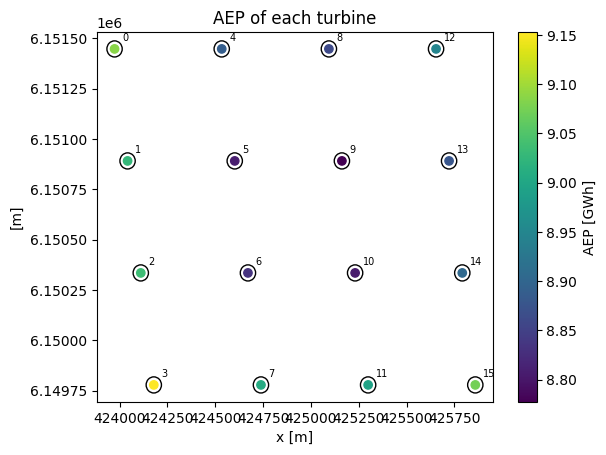

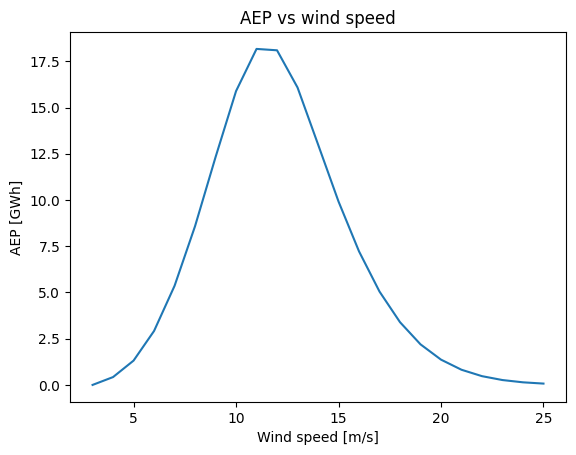

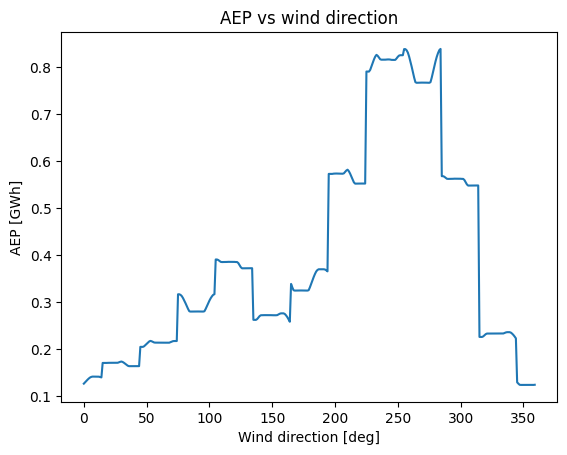

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()
aep = simulationResult.aep()
windTurbines.plot(wt16_x,wt16_y) # create basic plot of individual wind turbines (numbered black circles)
c =plt.scatter(wt16_x, wt16_y, c=aep.sum(['wd','ws'])) # Visualize AEP (across wd and ws) per WT as color gradient dots
plt.colorbar(c, label='AEP [GWh]')
plt.title('AEP of each turbine')
plt.xlabel('x [m]')
plt.ylabel('[m]')

plt.figure()
aep.sum(['wt','wd']).plot() # plot against wind direction
plt.xlabel("Wind speed [m/s]")
plt.ylabel("AEP [GWh]")
plt.title('AEP vs wind speed')

plt.figure()
aep.sum(['wt','ws']).plot() # plot against wind speed
plt.xlabel("Wind direction [deg]")
plt.ylabel("AEP [GWh]")
plt.title('AEP vs wind direction')

### Plotting flow maps

It is also possible to plot the wind farm wake map. This shows the wake behavior for each turbine given the flow cases studied.

You can change the values of the wind speed and wind direction to visualize the wake maps for different flow cases.

Text(0.5, 1.0, 'Wake map for 10 m/s and 270 deg')

<Figure size 640x480 with 0 Axes>

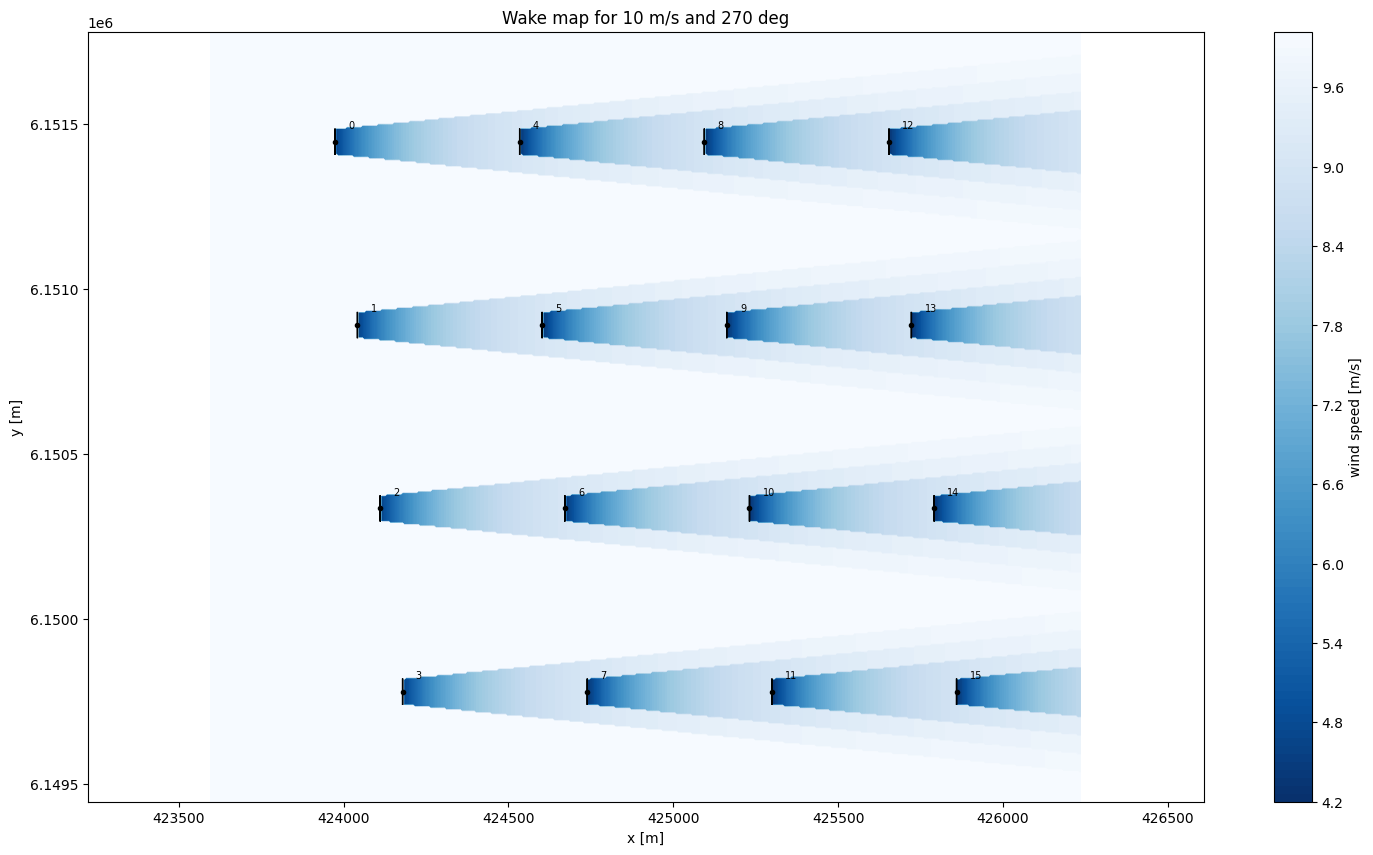

In [45]:
wind_speed = 10
wind_direction = 270

plt.figure()
flow_map = simulationResult.flow_map(ws=wind_speed, wd=wind_direction)
plt.figure(figsize=(18,10))
flow_map.plot_wake_map()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Wake map for' + f' {wind_speed} m/s and {wind_direction} deg')

And having some fun with background images:

Text(0.5, 1.0, 'Wake map for 15 m/s and 245 deg')

<Figure size 640x480 with 0 Axes>

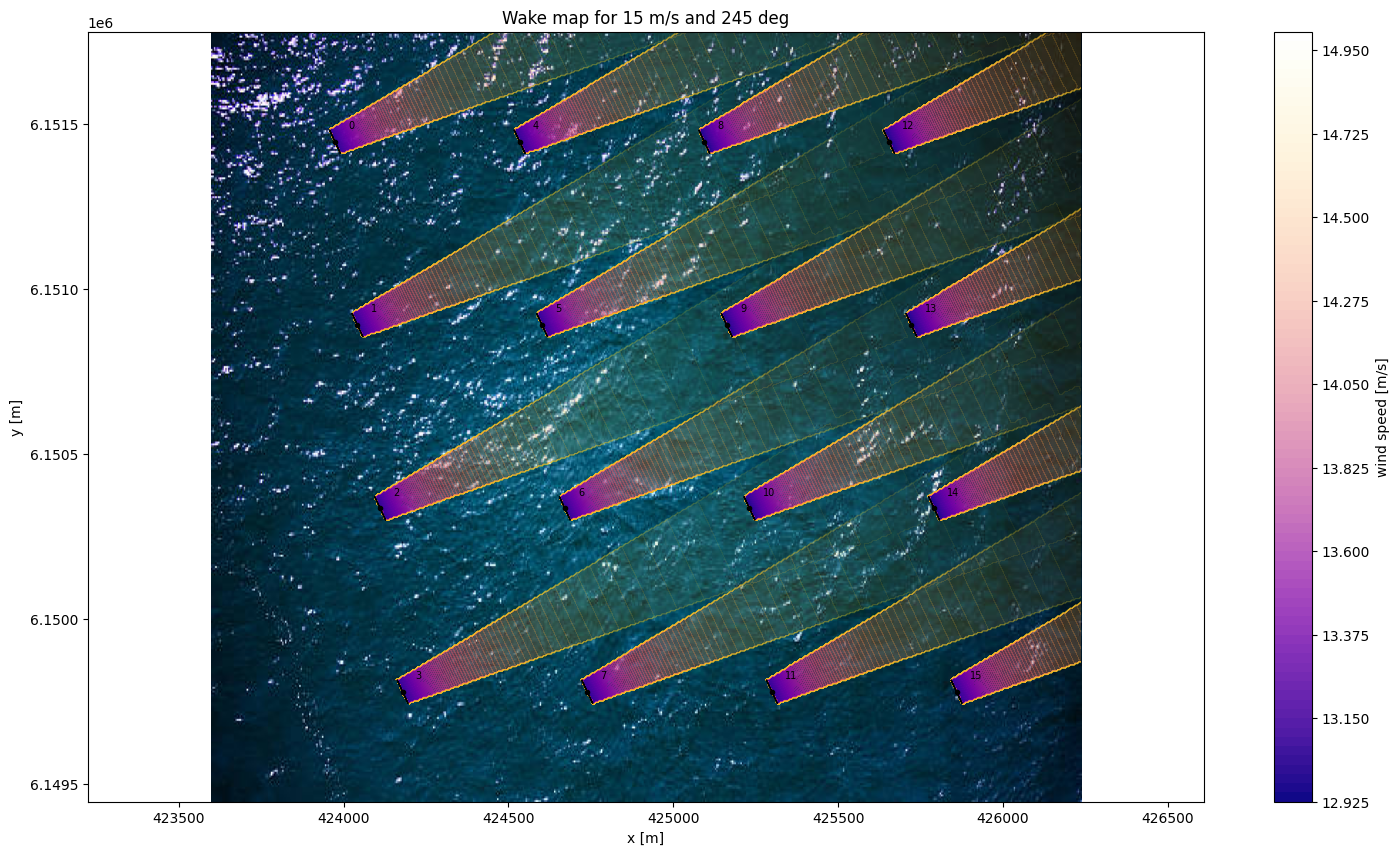

In [44]:
import matplotlib.colors as mcolors
import numpy as np

wind_speed = 15
wind_direction = 245

# Basis-Colormap holen (Standard von plot_wake_map: 'Blues_r')
base_cmap = plt.get_cmap('plasma')

# 256 Stützfarben aus der Colormap auslesen -> Array der Form (256, 4): R,G,B,A pro Zeile
colors = base_cmap(np.linspace(0, 1, 256))

# Alpha-Spalte (letzte Spalte) überschreiben:
# Bei 'Blues_r' ist Index 0 = dunkelblau (starker Wake), Index 255 = weiss (kein Wake)
alphas = np.linspace(1.0, 0.0, 256)
colors[:, -1] = alphas

# Neue Colormap mit variabler Transparenz bauen
transparent_cmap = mcolors.ListedColormap(colors)

plt.figure()
flow_map = simulationResult.flow_map(ws=wind_speed, wd=wind_direction)
fig, ax = plt.subplots(figsize=(18, 10))

# Background image (nice to have)
img = plt.imread('sea-surface.jpg')
x_min, x_max = float(flow_map.x.min()), float(flow_map.x.max())
y_min, y_max = float(flow_map.y.min()), float(flow_map.y.max())
ax.imshow(img, extent=[x_min, x_max, y_min, y_max], aspect='auto', zorder=0)

flow_map.plot_wake_map(ax=ax, cmap=transparent_cmap)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Wake map for {wind_speed} m/s and {wind_direction} deg')